# 2. 딥러닝 입문과 신경망 기초

> 이 노트북은 강의 자료에서 자동 변환되었습니다.  
> Google Colab에서 `런타임 > 런타임 유형 변경 > GPU`로 설정 후 실행하세요.


# 2. 딥러닝 입문과 신경망 기초

## 학습 목표

- AI, 머신러닝, 딥러닝의 포함 관계를 구분하고 퍼셉트론과 MLP의 의미를 이해한다.
- 활성화 함수가 왜 필요한지 실험 결과와 함께 설명할 수 있다.

 MNIST 데모를 실행해보며 머신러닝과 딥러닝의 위치, 퍼셉트론, MLP, 활성화 함수의 역할을 큰 흐름으로 연결합니다.

## 진행 순서

1. [입문자가 자주 하는 오해](#part1)
2. [MNIST로 모델 학습해보기](#part2)
3. [퍼셉트론과 인공신경망 기초](#part3)
4. [MLP(다층 퍼셉트론) 구조](#part4)
5. [활성화함수 진화사 (Sigmoid -> ReLU -> GELU)](#part5)
6. [활성화함수 비교 실험](#part6)

## 1. 입문자가 자주 하는 오해

딥러닝을 처음 배울 때 가장 많이 나오는 오해는 아래와 같습니다.

| 오개념 | 올바른 이해 |
|:------:|:------:|
| 딥러닝과 머신러닝은 같은 것이다 | 딥러닝은 머신러닝의 하위 집합이다 |
| `deep`은 심오하다는 뜻이다 | `deep`은 층(layer)이 깊다는 구조적 의미다 |
| 수학을 잘해야만 딥러닝을 배울 수 있다 | 비유와 실험을 통해 먼저 이해한다 |
| 딥러닝은 데이터가 엄청 많아야만 가능하다 | 전이학습 등으로 적은 데이터에서도 시작할 수 있다 |
| 딥러닝 모델은 완전한 블랙박스다 | 시각화 도구로 내부를 어느 정도 관찰할 수 있다 |


### 핵심 정리
- **AI**는 가장 넓은 개념입니다.
- **ML**은 데이터에서 규칙을 학습하는 방법입니다.
- **DL**은 여러 층의 신경망을 사용하는 머신러닝입니다.

즉, **모든 딥러닝은 머신러닝이지만, 모든 머신러닝이 딥러닝은 아닙니다.**


In [84]:
!pip install -q mermaid-py

In [85]:
from mermaid import Mermaid

Mermaid("""
flowchart TB
    A[인공지능 AI] --> B[머신러닝 ML]
    B --> C[딥러닝 DL]
    A_note[규칙 기반 시스템 탐색 추천]
    B_note[회귀 결정트리 SVM]
    C_note[CNN RNN Transformer]
    A --- A_note
    B --- B_note
    C --- C_note

    classDef core fill:#E8F0FE,stroke:#1D4ED8,stroke-width:2px,color:#111827
    classDef note fill:#F8FAFC,stroke:#94A3B8,stroke-width:1.5px,color:#334155
    class A,B,C core
    class A_note,B_note,C_note note
""")

## 2. MNIST로 모델 학습해보기


In [86]:
from mermaid import Mermaid

Mermaid("""
flowchart LR
    A["한글폰트준비\n(한글출력문제)"] --> B["데이터 로드\n(교과서 준비)"]
    B --> C["모델 정의\n(학생 배정)"]
    C --> D["학습\n(반복 공부)"]
    D --> E["예측\n(시험 응시)"]
    style A fill:#e5ff00,color:#000
    style E fill:#4CAF50,color:#fff
""")

###  0. 한글 폰트 설정 (Colab용)
Colab에서 matplotlib 한글이 깨지지 않도록 폰트를 설치합니다.


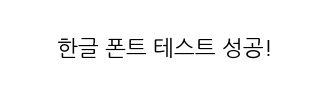

한글 폰트 설정 완료!


In [87]:
import subprocess
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 1) 나눔고딕 폰트 설치
subprocess.run(['apt-get', '-qq', 'update'], check=True)
subprocess.run(['apt-get', '-qq', '-y', 'install', 'fonts-nanum'], check=True)

# 2) 설치된 폰트 파일을 matplotlib에 직접 등록
font_files = fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum'])
for fpath in font_files:
    fm.fontManager.addfont(fpath)

# 3) 기본 폰트를 나눔고딕으로 설정
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 4) 테스트
fig, ax = plt.subplots(figsize=(4, 1))
ax.text(0.5, 0.5, '한글 폰트 테스트 성공!', ha='center', va='center', fontsize=16)
ax.axis('off')
plt.show()

print('한글 폰트 설정 완료!')

### 1. 데이터 로드 및 준비


In [88]:
import torch
import torchvision
import torchvision.transforms as transforms

# 이미지를 숫자(텐서)로 변환하는 설정
transform = transforms.Compose([
    transforms.ToTensor(),          # 이미지 -> 텐서 변환
    transforms.Normalize((0.5,), (0.5,))  # 값을 -1~1 범위로 정규화
])

# MNIST 학습 데이터 60,000장 다운로드
train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform
)

# MNIST 테스트 데이터 10,000장 다운로드
test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, download=True, transform=transform
)

print(f"학습 데이터: {len(train_dataset)}장")
print(f"테스트 데이터: {len(test_dataset)}장")



학습 데이터: 60000장
테스트 데이터: 10000장


In [89]:
print(type(train_dataset))
print(type(train_dataset[0]))
print(type(train_dataset[0][0]))
print(type(train_dataset[0][1]))
print(train_dataset[0][0].min().item())
print(train_dataset[0][0].max().item())
print(train_dataset[0][0].shape)

<class 'torchvision.datasets.mnist.MNIST'>
<class 'tuple'>
<class 'torch.Tensor'>
<class 'int'>
-1.0
1.0
torch.Size([1, 28, 28])


In [90]:
import numpy as np
print(type(train_dataset))
print(type(train_dataset[0]))
print(type(train_dataset[0][0]))
print(type(train_dataset[0][1]))
print(np.array(train_dataset[0][0]).min().item())
print(np.array(train_dataset[0][0]).max().item())
print(train_dataset[0][0])
print(np.array(train_dataset[0][0]).shape)

<class 'torchvision.datasets.mnist.MNIST'>
<class 'tuple'>
<class 'torch.Tensor'>
<class 'int'>
-1.0
1.0
tensor([[[-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
         [-1.000

**핵심**: 데이터 로드는 한 줄(`torchvision.datasets.MNIST`)로 완료된다. 60,000장의 손글씨 이미지가 자동으로 다운로드된다.

#### 손글씨 이미지 시각화


torch.Size([1, 28, 28]) torch.Size([28, 28])
torch.Size([1, 28, 28]) torch.Size([28, 28])
torch.Size([1, 28, 28]) torch.Size([28, 28])
torch.Size([1, 28, 28]) torch.Size([28, 28])
torch.Size([1, 28, 28]) torch.Size([28, 28])
torch.Size([1, 28, 28]) torch.Size([28, 28])
torch.Size([1, 28, 28]) torch.Size([28, 28])
torch.Size([1, 28, 28]) torch.Size([28, 28])
torch.Size([1, 28, 28]) torch.Size([28, 28])
torch.Size([1, 28, 28]) torch.Size([28, 28])


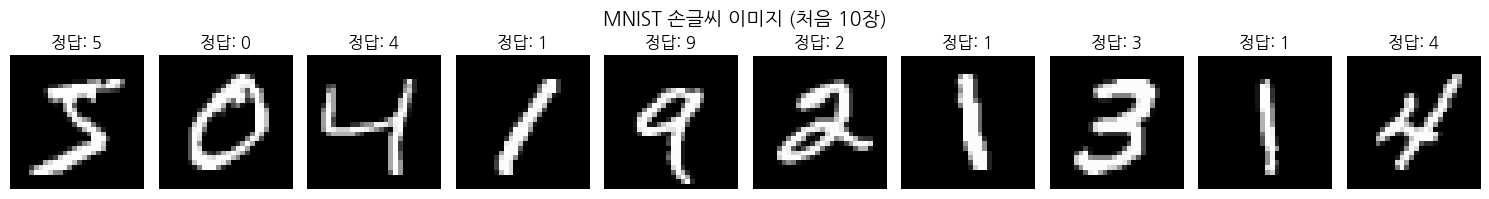

In [91]:
import matplotlib.pyplot as plt

# 처음 10장의 이미지를 출력
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i in range(10):
    image, label = train_dataset[i]
    print(image.shape,image.squeeze().shape)
    axes[i].imshow(image.squeeze(), cmap='gray')
    axes[i].set_title(f"정답: {label}")
    axes[i].axis('off')
plt.suptitle("MNIST 손글씨 이미지 (처음 10장)", fontsize=14)
plt.tight_layout()
plt.show()

![](./img/basic/basic002.png)

**예상 결과**: 0~9 숫자가 적힌 손글씨 이미지 10장이 가로로 나열되어 표시된다. 각 이미지 위에 정답 레이블이 표시된다.

**핵심**: 컴퓨터는 이 이미지를 28x28 = 784개의 숫자(픽셀 밝기)로 인식한다. 사람에게는 "5"라는 숫자가 보이지만, 컴퓨터에게는 784개의 숫자 배열이다.

### 2.  모델 정의 및 학습


In [92]:
import torch.nn as nn

# 간단한 2층 신경망 정의
model = nn.Sequential(
    nn.Flatten(),           # 28x28 이미지를 784개 숫자로 펼침
    nn.Linear(784, 128),    # 784개 입력 -> 128개 은닉 노드
    nn.ReLU(),              # 활성화함수
    nn.Linear(128, 10)      # 128개 은닉 -> 10개 출력 (0~9)
)

# 학습 설정
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)

# 3에폭 학습 (약 1~2분 소요)
for epoch in range(3):
    total_loss = 0
    for images, labels in train_loader:
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"에폭 {epoch+1}/3, 평균 손실: {total_loss/len(train_loader):.4f}")

# 테스트 정확도 측정
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64)
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        print(outputs.shape)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"\n테스트 정확도: {correct/total*100:.1f}%")



에폭 1/3, 평균 손실: 0.3907
에폭 2/3, 평균 손실: 0.1907
에폭 3/3, 평균 손실: 0.1388
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size

### 3. 예측


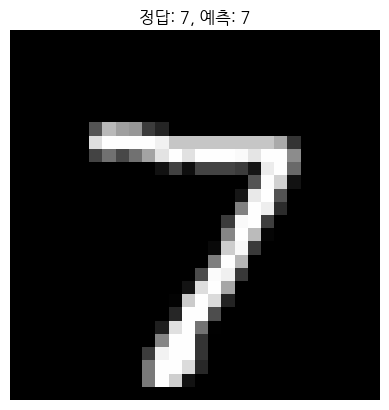

In [93]:
# 위의 학습된 모델로 개별 이미지 예측하기

# 테스트 이미지 1장 선택
test_image, true_label = test_dataset[0]

# 모델로 예측
with torch.no_grad():
    output = model(test_image.unsqueeze(0))  # 배치 차원 추가
    predicted_label = output.argmax(dim=1).item()

# 결과 시각화
plt.imshow(test_image.squeeze(), cmap='gray')
plt.title(f"정답: {true_label}, 예측: {predicted_label}")
plt.axis('off')
plt.show()

# 모델이 다른 이미지도 맞히는지 확인해보세요

![](./img/basic/basic003.png)


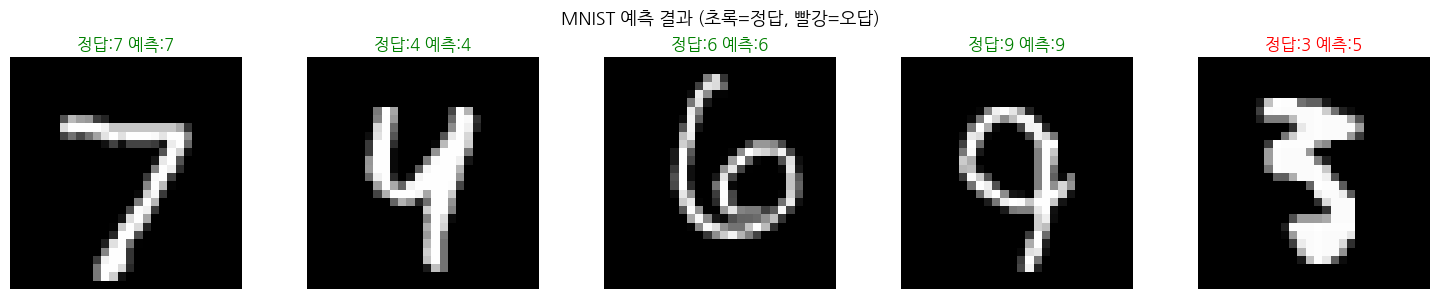

In [94]:
# 다양한 인덱스의 이미지를 예측하여 비교
test_indices = [0, 42, 100, 999, 2953]

fig, axes = plt.subplots(1, len(test_indices), figsize=(15, 3))
for i, idx in enumerate(test_indices):
    test_image, true_label = test_dataset[idx]
    with torch.no_grad():
        output = model(test_image.unsqueeze(0))
        predicted_label = output.argmax(dim=1).item()

    axes[i].imshow(test_image.squeeze(), cmap='gray')
    color = 'green' if predicted_label == true_label else 'red'
    axes[i].set_title(f"정답:{true_label} 예측:{predicted_label}", color=color)
    axes[i].axis('off')

plt.suptitle("MNIST 예측 결과 (초록=정답, 빨강=오답)", fontsize=13)
plt.tight_layout()
plt.show()

**예상 결과**: 5장의 이미지에 대한 예측 결과가 표시된다. 대부분 초록색(정답)이지만, 간혹 빨간색(오답)이 나타날 수 있다.

![](./img/basic/basic004.png)


In [95]:
# 모델이 틀린 이미지 찾기
wrong_predictions = []
with torch.no_grad():
    for idx in range(100):  # 처음 100장에서 오답 탐색
        image, true_label = test_dataset[idx]
        output = model(image.unsqueeze(0))
        pred = output.argmax(dim=1).item()
        if pred != true_label:
            wrong_predictions.append((idx, true_label, pred))

print(f"처음 100장 중 오답 수: {len(wrong_predictions)}개")
for idx, true, pred in wrong_predictions:
    print(f"  인덱스 {idx}: 정답={true}, 예측={pred}")



처음 100장 중 오답 수: 2개
  인덱스 8: 정답=5, 예측=6
  인덱스 33: 정답=4, 예측=0


전체 10000장 중 오답 수: 396개


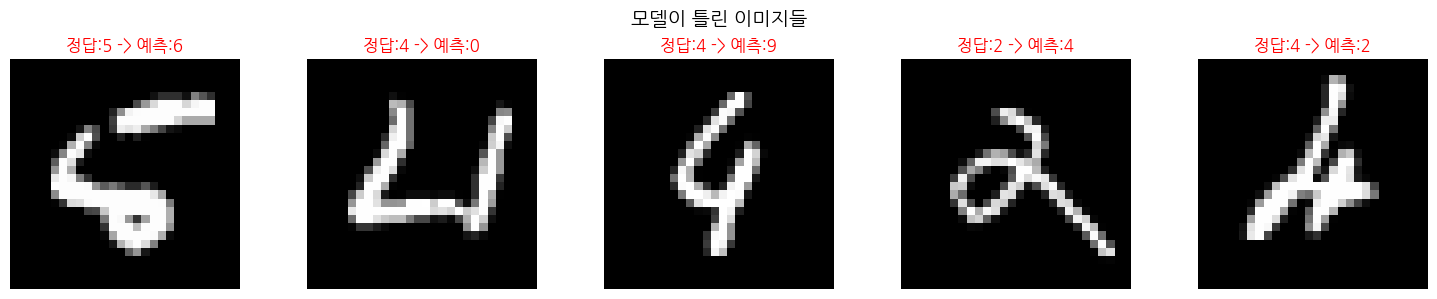

In [96]:
wrong_predictions = []
with torch.no_grad():
    for idx in range(len(test_dataset)):
        image, true_label = test_dataset[idx]
        output = model(image.unsqueeze(0))
        pred = output.argmax(dim=1).item()
        if pred != true_label:
            wrong_predictions.append((idx, true_label, pred, image))

print(f"전체 {len(test_dataset)}장 중 오답 수: {len(wrong_predictions)}개")

# 오답 중 처음 5개를 시각화
fig, axes = plt.subplots(1, min(5, len(wrong_predictions)), figsize=(15, 3))
for i in range(min(5, len(wrong_predictions))):
    idx, true, pred, image = wrong_predictions[i]
    axes[i].imshow(image.squeeze(), cmap='gray')
    axes[i].set_title(f"정답:{true} -> 예측:{pred}", color='red')
    axes[i].axis('off')
plt.suptitle("모델이 틀린 이미지들", fontsize=14)
plt.tight_layout()
plt.show()



![](./img/basic/basic005.png)

빨간 제목과 함께 모델이 헷갈린 이미지 5장이 표시된다. 흔히 3과 8, 4와 9, 7과 2 등이 혼동된다.

##### 흔한 실수 시나리오

| 실수 | 에러 메시지 | 해결 |
|:------:|:-----------:|:------:|
| 모델 학습 셀을 실행하지 않고 뒤에 코드 셀 실행 | `NameError: name 'model' is not defined` | 앞선 핵심 코드 셀을 위에서부터 순서대로 다시 실행한다 |
| Colab 런타임이 끊긴 후 재접속 | `RuntimeError: ...` 또는 변수 미정의 | "런타임 > 모두 실행"으로 전체 노트북을 다시 실행한다 |
| `test_dataset[99999]` 처럼 범위를 초과한 인덱스 사용 | `IndexError: index 99999 is out of bounds for axis 0 with size 10000` | 테스트 데이터는 10,000장이므로 인덱스를 0~9999 범위로 사용한다 |

---


## 3. 퍼셉트론과 인공신경망 기초


### ★ 정리 1: 3가지 학습 유형 사례 분류

다음 사례가 각각 어떤 학습 유형에 해당하는지 분류한다:

| 사례 | 학습 유형 | 이유 |
|:------:|:---------:|:------:|
| MNIST 손글씨 분류 | 지도학습 | 이미지와 정답 레이블(0~9)이 주어짐 |
| Netflix 추천 시스템 | 지도학습/비지도학습 | 시청 기록(데이터)으로 취향 패턴을 파악 |
| AlphaGo 바둑 | 강화학습 | 승패(보상)를 통해 최적 수를 학습 |
| 이메일 스팸 필터 | 지도학습 | 스팸/정상 레이블이 붙은 이메일로 학습 |
| 쇼핑몰 고객 세분화 | 비지도학습 | 정답 없이 구매 패턴에서 그룹을 발견 |

### ◇ 정리 2: 딥러닝이 강력한 영역과 그렇지 않은 영역

| 영역 | 딥러닝이 강한가? | 이유 |
|:------:|:--------------:|:------:|
| 이미지 인식 | 매우 강함 | CNN이 자동으로 시각적 특징(선, 모서리, 형태)을 추출 |
| 자연어 처리 | 매우 강함 | 트랜스포머가 문맥 정보를 자동으로 파악 |
| 정형 데이터(엑셀 테이블) | 보통 | 특징이 이미 명확하여 전통 ML(XGBoost 등)이 더 효율적인 경우가 많음 |
| 소규모 데이터 | 약함 | 층이 깊을수록 많은 데이터가 필요 (단, 전이학습으로 보완 가능 — Day 5) |


### ◇ 정리 3: 전통적 머신러닝과 딥러닝에서 데이타 처리의 차이점


In [97]:
from mermaid import Mermaid

Mermaid("""
graph LR
    subgraph DL["딥러닝"]
        B1["원본 데이터"] --> B2["자동 특징 추출\n+ 모델 학습"]
        B2 --> B3["예측"]
    end
    subgraph ML["전통적 머신러닝"]
        A1["원본 데이터"] --> A2["사람이 특징 설계\n(피처 엔지니어링)"]
        A2 --> A3["모델 학습"]
        A3 --> A4["예측"]
    end
    style DL fill:#E8F5E9
    style ML fill:#FFF3E0
""")

##### ◇ 정리 4 : 2012년 이후 기술 폭발의 원동력

2012년 이후 딥러닝이 폭발적으로 성장한 3가지 원동력:

| 원동력 | 설명 | 현재 상태 |
|:--------:|:------:|:---------:|
| 데이터 | 인터넷 보급으로 이미지, 텍스트, 영상 데이터가 폭증 | ImageNet 1,400만 장, Common Crawl 수조 토큰 |
| 연산 | NVIDIA GPU가 병렬 행렬 연산을 수천 배 가속 | Google Colab에서 무료 GPU(T4) 사용 가능 |
| 알고리즘 | ReLU, Dropout, BatchNorm, 트랜스포머 등 | 오픈소스(PyTorch, TensorFlow)로 누구나 접근 가능 |

### ◇ 정리 5 : 딥러닝 발전 흐름

- 1957: **퍼셉트론**
- 1969: **XOR**
- 1986: **MLP: multilayer perceptron (다층 퍼셉트론),역전파(Backpropagation)**
- 1998: **LeNet-5**
- 2012: **AlexNet**
- 2017: **트랜스포머(Transformer)**
- 2022: **ChatGPT**

### 1. 퍼셉트론 핵심 개념
![](./img/basic/basic001.png)
**퍼셉트론(Perceptron)**은 인간의 뇌 신경세포(뉴런)를 수학적으로 모방한 가장 단순한 인공 신경세포이다. 생물학적 뉴런이 여러 신호를 받아 합산하고, 임계값을 넘으면 다음 뉴런으로 신호를 전달하는 것과 같은 원리로 작동한다.

퍼셉트론의 4가지 구성 요소:

**1. 입력(Input, x)**: 외부에서 들어오는 데이터이다. 이미지의 픽셀값, 텍스트의 단어, 센서의 측정값 등이 될 수 있다. 퍼셉트론은 여러 개의 입력을 동시에 받을 수 있다.

**2. 가중치(Weight, w)**: 각 입력의 중요도를 나타내는 숫자이다. 가중치가 크면 해당 입력이 결과에 큰 영향을 미치고, 작으면 적은 영향을 미친다. 학습이란 바로 이 가중치를 적절히 조정하는 과정이다.

**3. 편향(Bias, b)**: 가중합에 더해지는 추가 상수이다. 편향은 퍼셉트론의 활성화 임계값을 조절하는 역할을 한다. 모든 입력이 0이어도 편향이 있으면 출력이 0이 아닐 수 있다.

**4. 활성화함수(Activation Function)**: 가중합 + 편향의 결과를 변환하여 최종 출력을 결정한다. 가장 단순한 형태는 계단 함수(step function)로, 결과가 0보다 크면 1(활성), 아니면 0(비활성)을 출력한다.

퍼셉트론의 연산 과정:
1. 각 입력에 가중치를 곱한다: x1*w1, x2*w2, ...
2. 모든 곱을 합산하고 편향을 더한다: z = x1*w1 + x2*w2 + ... + b
3. 활성화함수를 통과시켜 출력을 결정한다: y = f(z)


#### ★ 예시 1: AND 게이트를 퍼셉트론으로 구현

AND 게이트: **두 입력이 모두 1일 때만** 1을 출력합니다.

| x1 | x2 | 기대 출력 |
|:----:|:----:|:---------:|
| 0  | 0  | 0 |
| 0  | 1  | 0 |
| 1  | 0  | 0 |
| 1  | 1  | **1** |

가중치 `w1=0.5`, `w2=0.5`, 편향 `b=-0.7`로 설정하면 어떻게 될까요?

아래 코드를 실행하여 **계산 과정을 한 단계씩** 확인해봅시다.


In [98]:
# ===================================
# AND 게이트를 퍼셉트론으로 구현
# ===================================

# 퍼셉트론의 파라미터 (이 숫자 3개가 AND 논리를 만듭니다!)
w1 = 0.5   # 입력 x1의 가중치
w2 = 0.5   # 입력 x2의 가중치
b  = -0.7  # 편향

# 가능한 모든 입력 조합 (4가지)
inputs = [(0, 0), (0, 1), (1, 0), (1, 1)]

# AND 게이트의 정답
targets = [0, 0, 0, 1]

print('=== AND 게이트 ===')
print(f'파라미터: w1={w1}, w2={w2}, b={b}')
print()

for (x1, x2), target in zip(inputs, targets):
    # Step 1: 각 입력에 가중치를 곱한다
    weighted_1 = x1 * w1
    weighted_2 = x2 * w2

    # Step 2: 가중합을 구하고 편향을 더한다
    z = weighted_1 + weighted_2 + b

    # Step 3: 활성화 함수 (계단 함수: 0보다 크면 1, 아니면 0)
    y = 1 if z > 0 else 0

    # 결과 출력 (계산 과정을 모두 보여줌)
    mark = 'O' if y == target else 'X'
    print(f'  입력({x1}, {x2}): {x1}×{w1} + {x2}×{w2} + ({b}) = {z:.1f}'
          f'  →  {"0보다 큼" if z > 0 else "0 이하"}  →  출력: {y}  (정답: {target}) [{mark}]')

print()
print('핵심: 숫자 3개(w1, w2, b)만으로 AND 논리를 구현했습니다!')
print('"학습"이란 이 3개의 숫자를 올바르게 찾아가는 과정입니다.')

=== AND 게이트 ===
파라미터: w1=0.5, w2=0.5, b=-0.7

  입력(0, 0): 0×0.5 + 0×0.5 + (-0.7) = -0.7  →  0 이하  →  출력: 0  (정답: 0) [O]
  입력(0, 1): 0×0.5 + 1×0.5 + (-0.7) = -0.2  →  0 이하  →  출력: 0  (정답: 0) [O]
  입력(1, 0): 1×0.5 + 0×0.5 + (-0.7) = -0.2  →  0 이하  →  출력: 0  (정답: 0) [O]
  입력(1, 1): 1×0.5 + 1×0.5 + (-0.7) = 0.3  →  0보다 큼  →  출력: 1  (정답: 1) [O]

핵심: 숫자 3개(w1, w2, b)만으로 AND 논리를 구현했습니다!
"학습"이란 이 3개의 숫자를 올바르게 찾아가는 과정입니다.


#### ★ 예시 2: OR 게이트를 퍼셉트론으로 구현

OR 게이트: **두 입력 중 하나라도 1이면** 1을 출력합니다.

| x1 | x2 | 기대 출력 |
|:----:|:----:|:---------:|
| 0  | 0  | 0 |
| 0  | 1  | **1** |
| 1  | 0  | **1** |
| 1  | 1  | **1** |

AND와 뭐가 달라질까요? **편향(b)만 `-0.7`에서 `-0.3`으로 바꿔봅시다.**


In [99]:
# ===================================
# OR 게이트를 퍼셉트론으로 구현
# ===================================

# AND와 비교: 가중치는 같고 편향만 다릅니다!
w1 = 0.5   # 입력 x1의 가중치 (AND와 동일)
w2 = 0.5   # 입력 x2의 가중치 (AND와 동일)
b  = -0.3  # 편향만 변경! (-0.7 → -0.3)

inputs  = [(0, 0), (0, 1), (1, 0), (1, 1)]
targets = [0, 1, 1, 1]  # OR 게이트의 정답

print('=== OR 게이트 ===')
print(f'파라미터: w1={w1}, w2={w2}, b={b}  (AND 대비 편향만 변경!)')
print()

for (x1, x2), target in zip(inputs, targets):
    z = x1 * w1 + x2 * w2 + b   # 가중합 + 편향
    y = 1 if z > 0 else 0         # 계단 함수

    mark = 'O' if y == target else 'X'
    print(f'  입력({x1}, {x2}): {x1}×{w1} + {x2}×{w2} + ({b}) = {z:.1f}'
          f'  →  출력: {y}  (정답: {target}) [{mark}]')

print()
print('핵심: AND → OR로 바꾸는 데 편향 하나만 바꾸면 됩니다!')
print('편향(b)은 "얼마나 쉽게 활성화될 것인가"를 결정합니다.')
print('  b=-0.7 (AND): 둘 다 1이어야 간신히 통과')
print('  b=-0.3 (OR) : 하나만 1이어도 통과')

=== OR 게이트 ===
파라미터: w1=0.5, w2=0.5, b=-0.3  (AND 대비 편향만 변경!)

  입력(0, 0): 0×0.5 + 0×0.5 + (-0.3) = -0.3  →  출력: 0  (정답: 0) [O]
  입력(0, 1): 0×0.5 + 1×0.5 + (-0.3) = 0.2  →  출력: 1  (정답: 1) [O]
  입력(1, 0): 1×0.5 + 0×0.5 + (-0.3) = 0.2  →  출력: 1  (정답: 1) [O]
  입력(1, 1): 1×0.5 + 1×0.5 + (-0.3) = 0.7  →  출력: 1  (정답: 1) [O]

핵심: AND → OR로 바꾸는 데 편향 하나만 바꾸면 됩니다!
편향(b)은 "얼마나 쉽게 활성화될 것인가"를 결정합니다.
  b=-0.7 (AND): 둘 다 1이어야 간신히 통과
  b=-0.3 (OR) : 하나만 1이어도 통과


#### ◇ 예시 3: XOR 문제 — 퍼셉트론의 한계

XOR 게이트: **두 입력이 다를 때만** 1을 출력합니다.

| x1 | x2 | 기대 출력 |
|:----:|:----:|:---------:|
| 0  | 0  | 0 |
| 0  | 1  | **1** |
| 1  | 0  | **1** |
| 1  | 1  | 0 |

AND와 OR는 성공했으니, XOR도 되지 않을까요?

**아래 코드에서 `w1`, `w2`, `b` 값을 직접 바꿔보며 도전해보세요!**
어떤 값을 넣어도 4개를 모두 맞출 수 없다는 것을 체험해봅시다.


In [100]:
# ===================================
# XOR 게이트 도전! (직접 값을 바꿔보세요)
# ===================================

# TODO: 아래 값을 자유롭게 바꿔서 XOR을 만족시켜 보세요!
#       4개 모두 O가 나올 수 있을까요?
w1 = 0.5
w2 = 0.5
b  = -0.3

inputs  = [(0, 0), (0, 1), (1, 0), (1, 1)]
targets = [0, 1, 1, 0]  # XOR 게이트의 정답

print('=== XOR 게이트 도전 ===')
print(f'내가 설정한 파라미터: w1={w1}, w2={w2}, b={b}')
print()

correct_count = 0
for (x1, x2), target in zip(inputs, targets):
    z = x1 * w1 + x2 * w2 + b
    y = 1 if z > 0 else 0

    mark = 'O' if y == target else 'X'
    if y == target:
        correct_count += 1
    print(f'  입력({x1}, {x2}): {x1}×{w1} + {x2}×{w2} + ({b}) = {z:.1f}'
          f'  →  출력: {y}  (정답: {target}) [{mark}]')

print()
if correct_count == 4:
    print('축하합니다! 4개 모두 맞혔습니다! (정말요?? 다시 확인해보세요!)')
else:
    print(f'{correct_count}/4 정답... 다른 값으로 다시 도전해보세요!')
    print()
    print('힌트: 어떤 값을 넣어도 4개를 모두 맞출 수 없습니다.')
    print('      그 이유는 아래 시각화에서 확인해보세요!')

=== XOR 게이트 도전 ===
내가 설정한 파라미터: w1=0.5, w2=0.5, b=-0.3

  입력(0, 0): 0×0.5 + 0×0.5 + (-0.3) = -0.3  →  출력: 0  (정답: 0) [O]
  입력(0, 1): 0×0.5 + 1×0.5 + (-0.3) = 0.2  →  출력: 1  (정답: 1) [O]
  입력(1, 0): 1×0.5 + 0×0.5 + (-0.3) = 0.2  →  출력: 1  (정답: 1) [O]
  입력(1, 1): 1×0.5 + 1×0.5 + (-0.3) = 0.7  →  출력: 1  (정답: 0) [X]

3/4 정답... 다른 값으로 다시 도전해보세요!

힌트: 어떤 값을 넣어도 4개를 모두 맞출 수 없습니다.
      그 이유는 아래 시각화에서 확인해보세요!


##### 왜 XOR은 안 될까? — 시각화로 이해하기

퍼셉트론은 **직선 하나**로 0(빨간점)과 1(파란점)을 나누려고 합니다.

- **AND, OR**: 직선 하나로 나눌 수 있다 → 퍼셉트론으로 해결 가능!
- **XOR**: 직선 하나로는 절대 나눌 수 없다 → 퍼셉트론의 한계!

아래 코드를 실행하여 직접 확인해봅시다.


/tmp/ipykernel_1308/803676671.py:25: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x1, x2, c=color, marker=marker, s=200, zorder=5,


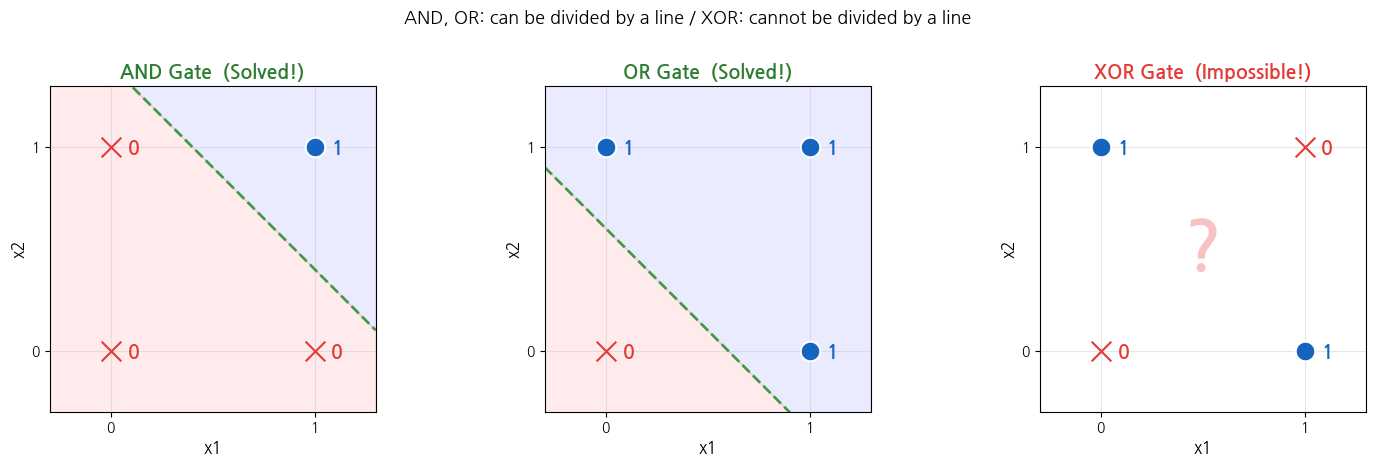

In [101]:
# ===================================
# 시각화: AND, OR, XOR의 결정 경계
# ===================================

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# 각 게이트의 데이터
gates = {
    'AND': {'targets': [0, 0, 0, 1], 'w1': 0.5, 'w2': 0.5, 'b': -0.7},
    'OR':  {'targets': [0, 1, 1, 1], 'w1': 0.5, 'w2': 0.5, 'b': -0.3},
    'XOR': {'targets': [0, 1, 1, 0], 'w1': None, 'w2': None, 'b': None},
}
inputs = [(0, 0), (0, 1), (1, 0), (1, 1)]

for idx, (name, gate) in enumerate(gates.items()):
    ax = axes[idx]

    # 0과 1을 색으로 구분하여 점 찍기
    for (x1, x2), t in zip(inputs, gate['targets']):
        color = '#1565C0' if t == 1 else '#E53935'     # 파랑=1, 빨강=0
        marker = 'o' if t == 1 else 'x'                # 동그라미=1, X=0
        ax.scatter(x1, x2, c=color, marker=marker, s=200, zorder=5,
                   edgecolors='white' if marker == 'o' else 'none', linewidths=1.5)
        # 출력값 표시
        ax.annotate(f'{t}', (x1, x2), textcoords='offset points',
                    xytext=(12, -5), fontsize=14, fontweight='bold', color=color)

    # 결정 경계 (직선) 그리기: w1*x1 + w2*x2 + b = 0  →  x2 = -(w1*x1 + b) / w2
    if gate['w1'] is not None:
        x_line = np.linspace(-0.3, 1.3, 100)
        x2_line = -(gate['w1'] * x_line + gate['b']) / gate['w2']
        ax.plot(x_line, x2_line, 'g--', linewidth=2, alpha=0.7,
                label='decision boundary')
        # 영역 색칠
        ax.fill_between(x_line, x2_line, 1.5, alpha=0.08, color='blue')
        ax.fill_between(x_line, -0.5, x2_line, alpha=0.08, color='red')
        ax.set_title(f'{name} Gate  (Solved!)', fontsize=14, fontweight='bold', color='#2E7D32')
    else:
        # XOR: 직선으로 나눌 수 없음을 표시
        ax.text(0.5, 0.5, '?', ha='center', va='center',
                fontsize=50, color='#E53935', alpha=0.3, fontweight='bold')
        ax.set_title(f'{name} Gate  (Impossible!)', fontsize=14, fontweight='bold', color='#E53935')

    ax.set_xlim(-0.3, 1.3)
    ax.set_ylim(-0.3, 1.3)
    ax.set_xlabel('x1', fontsize=12)
    ax.set_ylabel('x2', fontsize=12)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')

plt.suptitle('AND, OR: can be divided by a line / XOR: cannot be divided by a line',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**실행 결과:**


파란 점(o) = 출력 1,  빨간 점(x) = 출력 0
초록 점선 = 퍼셉트론이 그은 결정 경계 (직선)

AND, OR: 직선 하나로 파란 점과 빨간 점을 나눌 수 있다  → 퍼셉트론으로 해결 가능!
XOR:     직선 하나로는 절대 나눌 수 없다              → 퍼셉트론의 한계!

이것이 1969년 민스키가 증명한 퍼셉트론의 한계이며, 1차 AI 겨울의 원인입니다.
해결책은? → "층을 쌓는 것" = MLP(다층 퍼셉트론) 

![](./img/basic/basic006.png)

##### 퍼셉트론이 스스로 정답을 찾아가는 과정 (학습)

지금까지는 우리가 **직접 가중치와 편향 값을 정해줬습니다.**
하지만 실제 딥러닝에서는 컴퓨터가 **스스로 올바른 값을 찾아갑니다.**

어떻게? 아이디어는 단순합니다:

1. 가중치와 편향을 **아무 값**으로 시작한다 (랜덤)
2. 예측이 **틀리면**, 정답에 가까워지도록 값을 **조금씩 수정**한다
3. 이 과정을 **반복**한다

> 이것이 바로 **"학습(Training)"**의 핵심 원리입니다!
> Day 2에서 배울 "경사하강법"과 "역전파"가 바로 이 "조금씩 수정"하는 방법입니다.

아래 코드에서 퍼셉트론이 AND, OR 게이트의 정답을 **스스로 찾아가는 과정**을 관찰해봅시다.


In [102]:
# ===================================
# 퍼셉트론 학습: 스스로 정답을 찾아가기
# ===================================

import random

def train_perceptron(gate_name, targets, lr=0.1, max_epochs=100):
    """
    퍼셉트론이 가중치와 편향을 스스로 찾아가는 학습 과정

    gate_name : 게이트 이름 (표시용)
    targets   : 정답 리스트 [4개] — (0,0), (0,1), (1,0), (1,1) 순서
    lr        : 학습률 — 한 번에 얼마나 수정할지 (작을수록 조심스럽게)
    max_epochs: 최대 반복 횟수
    """
    inputs = [(0, 0), (0, 1), (1, 0), (1, 1)]

    # Step 1: 가중치와 편향을 랜덤으로 시작
    random.seed(42)
    w1 = random.uniform(-1, 1)
    w2 = random.uniform(-1, 1)
    b  = random.uniform(-1, 1)

    print(f'=== {gate_name} 게이트 학습 ===')
    print(f'정답: {targets}')
    print(f'시작값: w1={w1:.2f}, w2={w2:.2f}, b={b:.2f}  (랜덤!)')
    print()

    for epoch in range(1, max_epochs + 1):
        error_count = 0  # 이번 라운드에서 틀린 횟수

        for (x1, x2), target in zip(inputs, targets):
            # 예측
            z = x1 * w1 + x2 * w2 + b
            pred = 1 if z > 0 else 0

            # 오차 = 정답 - 예측  (맞으면 0, 틀리면 +1 또는 -1)
            error = target - pred

            if error != 0:  # 틀렸을 때만 수정!
                error_count += 1
                # Step 2: 가중치와 편향을 오차 방향으로 조금씩 수정
                w1 = w1 + lr * error * x1
                w2 = w2 + lr * error * x2
                b  = b  + lr * error

        # 진행 상황 출력: 처음 5번 + 마지막 에폭
        is_last = (epoch == max_epochs)
        if epoch <= 5 or error_count == 0 or is_last:
            preds = [1 if (x1*w1 + x2*w2 + b) > 0 else 0 for x1, x2 in inputs]
            marks = ['O' if p == t else 'X' for p, t in zip(preds, targets)]
            if epoch == 6 and not (error_count == 0 or is_last):
                print(f'  ...')
            print(f'  에폭 {epoch:>2}: 예측={preds}  정답={targets}  '
                  f'결과=[{", ".join(marks)}]  '
                  f'w1={w1:.2f}, w2={w2:.2f}, b={b:.2f}')

        # 에폭 6에서 생략 표시 (처음 5번 출력 후)
        elif epoch == 6:
            print(f'  ...')

        # Step 3: 모두 맞혔으면 학습 종료!
        if error_count == 0:
            print(f'\n  {epoch}번 만에 모든 정답을 찾았습니다!')
            print(f'  최종 파라미터: w1={w1:.2f}, w2={w2:.2f}, b={b:.2f}')
            return w1, w2, b

    # 마지막까지 정답을 못 찾은 경우
    preds = [1 if (x1*w1 + x2*w2 + b) > 0 else 0 for x1, x2 in inputs]
    correct = sum(1 for p, t in zip(preds, targets) if p == t)
    print(f'\n  {max_epochs}번 반복했지만 정답을 찾지 못했습니다. ({correct}/4 정답)')
    print(f'  최종 파라미터: w1={w1:.2f}, w2={w2:.2f}, b={b:.2f}')
    print(f'  최종 예측:     {preds}  (정답: {targets})')
    return w1, w2, b


# AND 게이트 학습
print('=' * 55)
w1_and, w2_and, b_and = train_perceptron('AND', [0, 0, 0, 1])

print()
print('=' * 55)
# OR 게이트 학습
w1_or, w2_or, b_or = train_perceptron('OR', [0, 1, 1, 1])

print()
print('=' * 55)
# XOR 게이트 학습 — 과연 찾을 수 있을까?
w1_xor, w2_xor, b_xor = train_perceptron('XOR', [0, 1, 1, 0])


=== AND 게이트 학습 ===
정답: [0, 0, 0, 1]
시작값: w1=0.28, w2=-0.95, b=-0.45  (랜덤!)

  에폭  1: 예측=[0, 0, 1, 0]  정답=[0, 0, 0, 1]  결과=[O, O, X, X]  w1=0.38, w2=-0.85, b=-0.35
  에폭  2: 예측=[0, 0, 1, 0]  정답=[0, 0, 0, 1]  결과=[O, O, X, X]  w1=0.38, w2=-0.75, b=-0.35
  에폭  3: 예측=[0, 0, 1, 0]  정답=[0, 0, 0, 1]  결과=[O, O, X, X]  w1=0.38, w2=-0.65, b=-0.35
  에폭  4: 예측=[0, 0, 1, 0]  정답=[0, 0, 0, 1]  결과=[O, O, X, X]  w1=0.38, w2=-0.55, b=-0.35
  에폭  5: 예측=[0, 0, 1, 0]  정답=[0, 0, 0, 1]  결과=[O, O, X, X]  w1=0.38, w2=-0.45, b=-0.35
  ...
  에폭 14: 예측=[0, 0, 0, 1]  정답=[0, 0, 0, 1]  결과=[O, O, O, O]  w1=0.28, w2=0.25, b=-0.45

  14번 만에 모든 정답을 찾았습니다!
  최종 파라미터: w1=0.28, w2=0.25, b=-0.45

=== OR 게이트 학습 ===
정답: [0, 1, 1, 1]
시작값: w1=0.28, w2=-0.95, b=-0.45  (랜덤!)

  에폭  1: 예측=[0, 0, 1, 0]  정답=[0, 1, 1, 1]  결과=[O, X, O, X]  w1=0.48, w2=-0.75, b=-0.15
  에폭  2: 예측=[1, 0, 1, 1]  정답=[0, 1, 1, 1]  결과=[X, X, O, O]  w1=0.58, w2=-0.55, b=0.05
  에폭  3: 예측=[1, 0, 1, 1]  정답=[0, 1, 1, 1]  결과=[X, X, O, O]  w1=0.58, w2=-0.45, b=0.05
 

##### 학습 결과 해석

| 게이트 | 학습 성공? | 의미 |
|:--------:|:---------:|:------:|
| AND | O | 퍼셉트론이 가중치/편향을 스스로 찾아냄 |
| OR  | O | 마찬가지로 스스로 찾아냄 |
| XOR | **X** | 100번을 반복해도 찾지 못함! |

AND와 OR는 컴퓨터가 **스스로 정답을 찾아갔지만**, XOR은 아무리 반복해도 **불가능**합니다.

> 이것은 우리가 값을 잘못 넣어서가 아니라, 단층 퍼셉트론의 **구조적 한계**입니다.
> 직선 하나로는 XOR 패턴을 나눌 수 없기 때문입니다.
>
> 해결책 → **층을 쌓자!** = MLP(다층 퍼셉트론)

##### 정리: AND / OR / XOR 비교

| 게이트 | 퍼셉트론으로 해결? | 가중치/편향 예시 | 핵심 |
|:--------:|:------------------:|:-----------------:|:------:|
| AND | O | w1=0.5, w2=0.5, b=**-0.7** | 둘 다 1이어야 통과 (높은 임계값) |
| OR | O | w1=0.5, w2=0.5, b=**-0.3** | 하나만 1이어도 통과 (낮은 임계값) |
| XOR | **X** | 어떤 값을 넣어도 불가 | 직선 하나로 분리 불가능 |

**핵심 교훈:**
- **학습**이란 가중치(w)와 편향(b) 숫자를 올바르게 찾아가는 과정입니다
- 편향(b) 하나만 바꿔도 AND → OR로 동작이 완전히 달라집니다
- 단층 퍼셉트론은 **직선 하나**밖에 못 그리기 때문에 XOR처럼 복잡한 문제를 풀 수 없습니다
- 해결책: **층을 쌓자!** → MLP(다층 퍼셉트론) = 다음 차시


##### 흔한 실수 시나리오

| 실수 | 증상 | 해결 |
|:------:|:------:|:------:|
| 가중합 계산에서 편향을 빠뜨림 | AND 결과가 맞지 않음 (예: 1,1에서 1.0 나옴) | "편향(b)을 마지막에 더해야 합니다" 확인 |
| 활성화 기준을 0 대신 0.5로 착각 | 결과가 반대로 나옴 | "0보다 크면 1, 아니면 0입니다 (계단 함수 기준 = 0)" 확인 |

---

## 4. MLP(다층 퍼셉트론) 구조

![](./img/basic/basic010.png)

### ★ 예시 1: XOR 문제를 MLP로 해결

2층 MLP(은닉층 1개, 노드 2개)로 XOR을 해결하는 과정:

| 층 | 역할 | 결과 |
|:----:|:------:|:------:|
| 은닉 노드 1 | "x1 OR x2" 판별 | (0,0)→0, (0,1)→1, (1,0)→1, (1,1)→1 |
| 은닉 노드 2 | "x1 AND x2" 판별 | (0,0)→0, (0,1)→0, (1,0)→0, (1,1)→1 |
| 출력 노드 | "은닉1이 1이면서 은닉2가 0" | OR 결과에서 AND 결과를 빼면 XOR |

은닉 노드 1은 "OR 직선"을, 은닉 노드 2는 "AND 직선"을 그린다. 출력 노드가 이 두 직선의 결과를 조합하면 XOR 문제가 해결된다. 즉, 직선 2개를 조합하여 비선형 분류를 달성한 것이다.

**핵심**: 은닉층의 각 노드가 서로 다른 직선을 담당하고, 출력층이 이 직선들을 조합하여 복잡한 경계를 만든다. 이것이 MLP의 핵심 원리이다.


#####  MLP가 XOR을 해결하는 과정

앞에서 단층 퍼셉트론은 100번을 반복해도 XOR을 풀지 못했습니다.

이제 **은닉층을 하나 추가한 MLP(다층 퍼셉트론)**로 같은 XOR 문제를 풀어봅시다.

아래 두 구조를 비교해보세요:
![](./img/basic/basic011.png)


In [103]:
# ===================================
# MLP(다층 퍼셉트론)로 XOR 문제 해결!
# ===================================
# 단층 퍼셉트론이 못 풀었던 XOR을,
# 은닉층 하나를 추가한 것만으로 해결합니다.

import torch
import torch.nn as nn

# ----- 1. XOR 데이터 준비 -----
X = torch.tensor([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=torch.float32)
y = torch.tensor([[0],    [1],    [1],    [0]],    dtype=torch.float32)

print('XOR 데이터:')
for i in range(4):
    print(f'  입력: {X[i].tolist()} → 정답: {int(y[i].item())}')
print()

# ----- 2. MLP 모델 만들기 -----
# 입력 2개 → 은닉층 2개 → 출력 1개
model = nn.Sequential(
    nn.Linear(2, 2),    # 입력(2) → 은닉층(2): 은닉 노드 2개가 각각 직선 하나를 담당
    nn.Sigmoid(),       # 활성화 함수: 0~1 사이로 변환
    nn.Linear(2, 1),    # 은닉층(2) → 출력(1): 두 직선의 결과를 조합
    nn.Sigmoid(),       # 최종 출력도 0~1 사이
)

print('모델 구조:')
print(model)
print()

# 파라미터 수 확인
total_params = sum(p.numel() for p in model.parameters())
print(f'총 학습 파라미터: {total_params}개')
print('  - 입력→은닉: 가중치 2×2=4개 + 편향 2개 = 6개')
print('  - 은닉→출력: 가중치 2×1=2개 + 편향 1개 = 3개')
print(f'  - 합계: {total_params}개의 숫자를 학습으로 찾아야 합니다')

XOR 데이터:
  입력: [0.0, 0.0] → 정답: 0
  입력: [0.0, 1.0] → 정답: 1
  입력: [1.0, 0.0] → 정답: 1
  입력: [1.0, 1.0] → 정답: 0

모델 구조:
Sequential(
  (0): Linear(in_features=2, out_features=2, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=2, out_features=1, bias=True)
  (3): Sigmoid()
)

총 학습 파라미터: 9개
  - 입력→은닉: 가중치 2×2=4개 + 편향 2개 = 6개
  - 은닉→출력: 가중치 2×1=2개 + 편향 1개 = 3개
  - 합계: 9개의 숫자를 학습으로 찾아야 합니다


In [104]:
# ----- 3. 학습 (컴퓨터가 스스로 정답을 찾아감) -----

criterion = nn.BCELoss()   # 손실 함수: 예측이 정답과 얼마나 다른지 계산
optimizer = torch.optim.SGD(model.parameters(), lr=1.0)  # 경사하강법으로 파라미터 수정

print('학습 시작!')
print(f'{"에폭":>6} | {"손실":>8} | 예측 → 결과')
print('-' * 55)

for epoch in range(1, 5001):
    # 예측
    pred = model(X)

    # 손실(오차) 계산: 예측이 정답과 얼마나 다른가?
    loss = criterion(pred, y)

    # 역전파 + 파라미터 수정 (Day 2에서 자세히 배움)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # 진행 상황 출력 (500번마다)
    if epoch % 500 == 0 or epoch == 1:
        with torch.no_grad():
            preds_round = [int(p.round().item()) for p in model(X)]
            targets_list = [int(t.item()) for t in y]
            marks = ['O' if p == t else 'X' for p, t in zip(preds_round, targets_list)]
        print(f'{epoch:>6} | {loss.item():>8.4f} | {preds_round}  [{", ".join(marks)}]')

print()
print('학습 완료!')

학습 시작!
    에폭 |       손실 | 예측 → 결과
-------------------------------------------------------
     1 |   0.6944 | [0, 0, 0, 0]  [O, X, X, O]
   500 |   0.6932 | [0, 1, 0, 1]  [O, O, X, X]
  1000 |   0.6923 | [0, 1, 0, 1]  [O, O, X, X]
  1500 |   0.0898 | [0, 1, 1, 0]  [O, O, O, O]
  2000 |   0.0170 | [0, 1, 1, 0]  [O, O, O, O]
  2500 |   0.0091 | [0, 1, 1, 0]  [O, O, O, O]
  3000 |   0.0062 | [0, 1, 1, 0]  [O, O, O, O]
  3500 |   0.0047 | [0, 1, 1, 0]  [O, O, O, O]
  4000 |   0.0037 | [0, 1, 1, 0]  [O, O, O, O]
  4500 |   0.0031 | [0, 1, 1, 0]  [O, O, O, O]
  5000 |   0.0027 | [0, 1, 1, 0]  [O, O, O, O]

학습 완료!


In [105]:
# ----- 4. 최종 결과 확인 -----

print('=' * 50)
print('  XOR 문제 최종 결과')
print('=' * 50)
print()

with torch.no_grad():
    predictions = model(X)
    print(f'{"입력":<12} {"정답":>4} {"예측(확률)":>10} {"예측(반올림)":>10} {"결과":>4}')
    print('-' * 50)

    all_correct = True
    for i in range(4):
        x_str = f'({int(X[i][0])}, {int(X[i][1])})'
        target = int(y[i].item())
        prob = predictions[i].item()
        pred = int(predictions[i].round().item())
        mark = 'O' if pred == target else 'X'
        if pred != target:
            all_correct = False
        print(f'  {x_str:<10} {target:>4} {prob:>10.4f} {pred:>10} {mark:>4}')

print()
if all_correct:
    print('모든 XOR 입력을 정확히 맞혔습니다!')
    print()
    print('비교:')
    print('  단층 퍼셉트론 → 100번 반복해도 실패 (직선 1개의 한계)')
    print('  MLP (은닉층 1개) → 성공! (직선 2개를 조합)')
    print()
    print('이것이 "층을 쌓는 것"의 힘입니다!')
else:
    print('아직 완벽하지 않습니다. 학습 에폭을 늘려보세요.')

  XOR 문제 최종 결과

입력             정답     예측(확률)    예측(반올림)   결과
--------------------------------------------------
  (0, 0)        0     0.0034          0    O
  (0, 1)        1     0.9976          1    O
  (1, 0)        1     0.9976          1    O
  (1, 1)        0     0.0025          0    O

모든 XOR 입력을 정확히 맞혔습니다!

비교:
  단층 퍼셉트론 → 100번 반복해도 실패 (직선 1개의 한계)
  MLP (은닉층 1개) → 성공! (직선 2개를 조합)

이것이 "층을 쌓는 것"의 힘입니다!


/tmp/ipykernel_1308/2211658321.py:32: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(inputs_np[i, 0], inputs_np[i, 1], c=color, marker=marker,
/tmp/ipykernel_1308/2211658321.py:50: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(inputs_np[i, 0], inputs_np[i, 1], c=color, marker=marker,


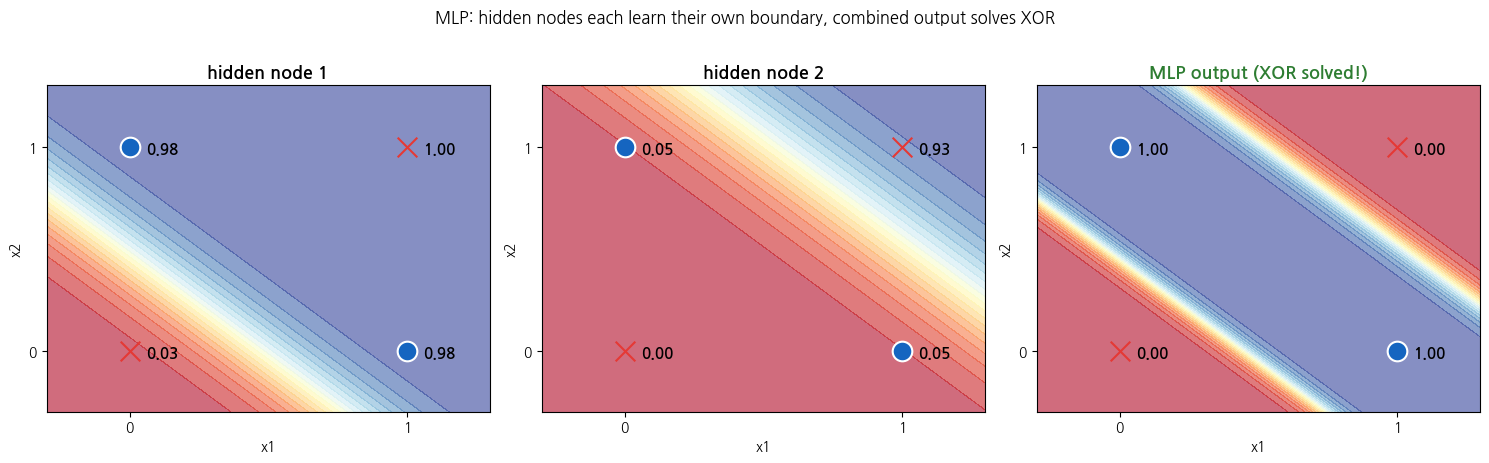

In [106]:
# ----- 5. 은닉층이 무엇을 배웠는지 들여다보기 -----
# MLP의 은닉 노드 2개가 각각 어떤 역할을 하는지 확인합니다

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# 은닉층의 출력 확인
with torch.no_grad():
    # 은닉층만 통과시키기 (첫 번째 Linear + Sigmoid)
    hidden_out = torch.sigmoid(model[0](X))
    final_out = model(X)

inputs_np = X.numpy()
targets_np = y.numpy().flatten()

# 결정 경계를 그리기 위한 격자
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

# 서브플롯 1: 은닉 노드 1의 결정 경계
with torch.no_grad():
    h = torch.sigmoid(model[0](grid)).numpy()

for idx, title in enumerate(['hidden node 1', 'hidden node 2']):
    ax = axes[idx]
    ax.contourf(xx, yy, h[:, idx].reshape(xx.shape), levels=20, cmap='RdYlBu', alpha=0.6)
    for i in range(4):
        color = '#1565C0' if targets_np[i] == 1 else '#E53935'
        marker = 'o' if targets_np[i] == 1 else 'x'
        ax.scatter(inputs_np[i, 0], inputs_np[i, 1], c=color, marker=marker,
                   s=200, zorder=5, edgecolors='white' if marker == 'o' else 'none', linewidths=1.5)
        h_val = hidden_out[i, idx].item()
        ax.annotate(f'{h_val:.2f}', (inputs_np[i, 0], inputs_np[i, 1]),
                    textcoords='offset points', xytext=(12, -5), fontsize=11, fontweight='bold')
    ax.set_title(f'{title}', fontsize=13, fontweight='bold')
    ax.set_xlabel('x1'); ax.set_ylabel('x2')
    ax.set_xlim(-0.3, 1.3); ax.set_ylim(-0.3, 1.3)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])

# 서브플롯 3: MLP 최종 출력
ax = axes[2]
with torch.no_grad():
    z = model(grid).numpy().reshape(xx.shape)
ax.contourf(xx, yy, z, levels=20, cmap='RdYlBu', alpha=0.6)
for i in range(4):
    color = '#1565C0' if targets_np[i] == 1 else '#E53935'
    marker = 'o' if targets_np[i] == 1 else 'x'
    ax.scatter(inputs_np[i, 0], inputs_np[i, 1], c=color, marker=marker,
               s=200, zorder=5, edgecolors='white' if marker == 'o' else 'none', linewidths=1.5)
    pred_val = final_out[i].item()
    ax.annotate(f'{pred_val:.2f}', (inputs_np[i, 0], inputs_np[i, 1]),
                textcoords='offset points', xytext=(12, -5), fontsize=11, fontweight='bold')
ax.set_title('MLP output (XOR solved!)', fontsize=13, fontweight='bold', color='#2E7D32')
ax.set_xlabel('x1'); ax.set_ylabel('x2')
ax.set_xlim(-0.3, 1.3); ax.set_ylim(-0.3, 1.3)
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])

plt.suptitle('MLP: hidden nodes each learn their own boundary, combined output solves XOR',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


**실행 결과:**
![](./img/basic/basic007.png)

왼쪽/가운데: 은닉 노드 2개가 각각 배운 결정 경계 (직선 1개씩)
오른쪽: 두 은닉 노드의 결과를 조합한 최종 출력 → XOR 해결!

핵심: 직선 1개로 안 되면, 직선 여러 개를 조합하면 된다!
      이것이 "층을 쌓는 것"의 의미이고, MLP의 핵심 원리입니다.


#####  은닉층 수와 결정 경계의 관계

| 구조 | 결정 경계 | 표현 능력 |
|:------:|:---------:|:---------:|
| 단층 퍼셉트론 (은닉층 없음) | 직선 1개 | AND, OR만 가능 |
| 은닉층 1개 (노드 적음) | 꺾인 선 | XOR, 단순 비선형 |
| 은닉층 1개 (노드 많음) | 부드러운 곡선 | 대부분의 2D 패턴 |
| 은닉층 2개 이상 | 복잡한 곡면 | 이미지 인식, 언어 처리 |

수학적으로, 은닉층 1개에 충분한 노드가 있으면 어떤 연속 함수도 근사할 수 있다(만능 근사 정리). 하지만 실용적으로는 노드를 무한히 늘리기보다 층을 깊게 쌓는 것이 더 효율적이다. 이것이 "deep" learning의 이유이다.



##### 흔한 실수 시나리오

| 실수 | 증상 | 해결 |
|:------:|:------:|:------:|
| 입력층도 가중치가 있다고 생각 | 파라미터 수 계산이 맞지 않음 | "입력층은 데이터를 전달만 합니다. 가중치는 층 사이의 연결에만 있습니다" |
| "층을 쌓으면 계산이 기하급수적으로 증가"로 착각 | 층 추가가 불가능하다고 느낌 | "GPU가 이 병렬 계산을 효율적으로 처리합니다."|

---


## 5. 활성화함수 진화사 (Sigmoid -> ReLU -> GELU)

앞에서 MLP의 구조를 배웠다. 은닉층이 여러 직선을 만들고 조합하여 비선형 분류를 가능하게 한다는 것을 이해했다. 마지막에 "활성화함수 없이 MLP를 쌓으면 직선 하나와 같다"는 복선을 깔았다. 

확인 질문: "MLP에서 비선형 분류가 가능한 이유가 무엇이었나요?" 

예상 답변: "은닉층." 

후속: "맞습니다. 그런데 은닉층에서 비선형성을 만드는 진짜 주인공이 있습니다."

**학습목표**: Sigmoid, ReLU, Leaky ReLU 활성화함수의 그래프 형태와 특성을 설명하고, 각각의 장단점을 비교할 수 있다. 특히 Sigmoid의 기울기소실 문제와 ReLU의 해결 원리를 이해한다.



##### 핵심 개념

**활성화함수(Activation Function)**는 신경망의 각 노드에서 가중합의 결과를 비선형으로 변환하는 함수이다. 활성화함수가 없으면 여러 층을 쌓아도 결국 하나의 선형 변환(행렬 곱셈)으로 축소되어, 단층 퍼셉트론과 동일한 능력만 가진다. 활성화함수가 "비선형성"을 주입하여 MLP가 곡선을 그릴 수 있게 만든다.

활성화함수는 70년간 진화해왔으며, 이 진화 역시 "문제-해결" 패턴을 따른다.

![](./img/basic/basic012.png)

**1. Sigmoid 함수 (1960~2000년대 주류)**

수식: f(x) = 1 / (1 + e^(-x))

특성:
- 출력 범위: 0~1 (확률처럼 해석 가능)
- 그래프 형태: 부드러운 S자 곡선
- 장점: 출력을 확률로 해석할 수 있어 이진 분류 출력층에 적합

**치명적 문제 — 기울기소실(Vanishing Gradient)**: Sigmoid의 그래프에서 입력이 매우 크거나 매우 작으면, 그래프가 평평해진다(기울기가 0에 수렴). 역전파 과정에서 기울기를 곱해가며 전파하는데, 매우 작은 기울기가 여러 층에 걸쳐 곱해지면 최종 기울기가 사실상 0이 된다. 이로 인해 깊은 층의 가중치가 거의 업데이트되지 않아, 학습이 극도로 느려지거나 멈춘다. 이것이 2차 AI 겨울의 핵심 원인 중 하나이다.

**2. ReLU 함수 (2012년~ 현재 주류)**

수식: f(x) = max(0, x)

특성:
- 0 이하: 0 출력 (신호 차단)
- 0 이상: 입력 그대로 출력 (신호 통과)
- 그래프 형태: V자를 반으로 자른 형태 (0에서 꺾임)

장점:
- 양수 영역에서 기울기가 항상 1 — 기울기소실 문제를 대폭 완화
- 계산이 매우 단순 (max 연산 하나) — 학습 속도 향상
- 2012년 AlexNet이 ReLU를 사용하여 ImageNet 대회를 압도한 이후 딥러닝의 표준이 됨

**3. Leaky ReLU (ReLU의 보완)**

수식: f(x) = x if x > 0, else 0.01*x

특성:
- ReLU와 거의 동일하되, 음수 영역에서도 아주 작은 기울기(0.01)를 유지
- "죽은 ReLU 문제" 완화: ReLU에서 한 번 0이 된 노드가 영원히 비활성화되는 현상을 방지

**4. GELU (트랜스포머 시대)**

수식: f(x) = x * Φ(x) (Φ는 정규분포 누적함수)

특성:
- BERT, GPT 등 트랜스포머 모델에서 사용하는 최신 활성화함수
- ReLU처럼 양수를 통과시키되, 0 근처에서 부드러운 전환을 제공

| 특성 | Sigmoid | ReLU |
|:------:|:---------:|:------:|
| 출력 범위 | 0~1 | 0~무한대 |
| 기울기 최대값 | 0.25 (x=0에서) | 1 (양수 영역 전체) |
| 기울기소실 | 심각 (양 끝에서 기울기 ≈ 0) | 없음 (양수에서 기울기 = 1) |
| 계산 비용 | 높음 (지수 함수) | 낮음 (max 연산) |
| 2012년 이후 사용 빈도 | 출력층(이진 분류)에만 | 은닉층 표준 |

**핵심**: ReLU가 Sigmoid를 대체한 핵심 이유는 기울기소실 문제의 해결이다. Sigmoid의 기울기 최대값이 0.25인 반면, ReLU의 양수 기울기는 항상 1이다. 5층 신경망에서 기울기를 전파하면: Sigmoid는 0.25^5 = 0.001로 거의 사라지지만, ReLU는 1^5 = 1로 유지된다.

ReLU의 한계: 학습 중 가중치가 크게 음수로 업데이트되면, 해당 노드의 출력이 항상 0이 되어 "죽은 뉴런(dead neuron)"이 된다. 이 노드는 더 이상 학습에 참여하지 못한다.

Leaky ReLU의 해결: 음수 영역에서 0 대신 0.01*x를 출력하여 약한 기울기(0.01)를 유지한다. 이로써 죽은 뉴런 문제를 방지하면서 ReLU의 장점을 유지한다.

#### GELU — 트랜스포머 시대의 활성화함수

GELU는 "확률적 활성화"라는 아이디어에 기반한다. 입력값이 클수록 활성화될 확률이 높고, 작을수록 낮다. ReLU가 0에서 급격하게 꺾이는 반면, GELU는 0 근처에서 부드럽게 전환된다. 이 부드러운 전환이 트랜스포머 모델의 학습 안정성을 높인다. BERT, GPT, Claude 등 현재 대부분의 대규모 언어 모델이 GELU를 사용한다.

| 활성화함수 | 등장 시기 | 주 사용처 | "문제-해결" 맥락 |
|:-----------:|:---------:|:---------:|:---------------:|
| Sigmoid | 1960s~ | 이진 분류 출력층 | 최초의 부드러운 활성화 |
| ReLU | 2012~ | 대부분의 은닉층 | 기울기소실 해결 |
| Leaky ReLU | 2013~ | 은닉층 (ReLU 대안) | 죽은 ReLU 해결 |
| GELU | 2016~ | 트랜스포머 은닉층 | 부드러운 전환으로 학습 안정화 |



| 함수 | 출력 범위 | 기울기(양수) | 기울기(음수) | 장점 | 단점 |
|:------:|:---------:|:-----------:|:-----------:|:------:|:------:|
| Sigmoid | 0~1 | 최대 **0.25** | 최대 **0.25** | 확률 해석 | **기울기소실** |
| ReLU | **0**~무한대 | **1** | **0** | **기울기 유지, 계산 단순** | 죽은 뉴런 |
| Leaky ReLU | -무한대~무한대 | **1** | **0.01** | **죽은 뉴런 방지** | 하이퍼파라미터 |



##### 흔한 실수 시나리오

| 실수 | 증상 | 해결 |
|:------:|:------:|:------:|
| "ReLU가 항상 Sigmoid보다 좋다"고 일반화 | 출력층에서도 ReLU를 쓰려 함 | "출력층에서 확률이 필요하면 Sigmoid가 적합합니다. 은닉층에서는 ReLU가 표준입니다" |
| 기울기 = 출력값으로 혼동 | "Sigmoid 출력이 0.5면 기울기도 0.5" | "기울기는 함수의 기울어진 정도(미분값)이고, 출력값과 다릅니다. Sigmoid 출력이 0.5일 때 기울기는 0.25입니다" |

---


## 6. 활성화 함수 비교 실험


In [107]:
from mermaid import Mermaid

Mermaid("""
flowchart LR
    DATA["MNIST\n데이터"] --> M1["MLP + Sigmoid"]
    DATA --> M2["MLP + ReLU"]
    DATA --> M3["MLP + Leaky ReLU"]
    M1 --> R1["결과 1"]
    M2 --> R2["결과 2"]
    M3 --> R3["결과 3"]
    style DATA fill:#FFF3E0
""")

In [108]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# 데이터 로드
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64)

# 모델 정의 함수 (활성화함수를 매개변수로 받음)
def create_model(activation_fn):
    return nn.Sequential(
        nn.Flatten(),
        nn.Linear(784, 128),
        activation_fn,          # ← 여기만 교체!
        nn.Linear(128, 10)
    )

# 학습 함수
def train_model(model, epochs=10, lr=0.01):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    history = {'loss': [], 'acc': []}

    for epoch in range(epochs):
        total_loss = 0
        correct = 0
        total = 0
        for images, labels in train_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        avg_loss = total_loss / len(train_loader)
        acc = correct / total * 100
        history['loss'].append(avg_loss)
        history['acc'].append(acc)
        print(f"에폭 {epoch+1}/{epochs} | 손실: {avg_loss:.4f} | 정확도: {acc:.1f}%")

    return history

print("데이터 로드 완료! 모델 정의 함수 준비 완료!")



데이터 로드 완료! 모델 정의 함수 준비 완료!


**핵심**: 모델 구조에서 활성화함수 한 줄(`activation_fn`)만 교체하여 실험할 수 있다. 이것이 통제 변인 실험의 핵심이다.

##### ★ 예시 1: Sigmoid 실험 실행


In [ ]:
print("=" * 50)
print("실험 1: Sigmoid 활성화함수")
print("=" * 50)

model_sigmoid = create_model(nn.Sigmoid())
history_sigmoid = train_model(model_sigmoid, epochs=10, lr=0.01)



실험 1: Sigmoid 활성화함수
에폭 1/10 | 손실: 1.7492 | 정확도: 62.2%


: 

Sigmoid는 학습이 느리게 시작되며, 10에폭 후에도 약 78~82% 정확도에 머문다.


##### ★ 예시 2: ReLU 실험 실행


In [ ]:
print("=" * 50)
print("실험 2 :  ReLU 활성화함수")
print("=" * 50)

model_relu = create_model(nn.ReLU())
history_relu = train_model(model_relu, epochs=10, lr=0.01)

##### ★ 예시 3: LeakyReLU 실험 실행


In [ ]:
print("=" * 50)
print("실험 3 :  LeakyReLU 활성화함수")
print("=" * 50)


model_leaky = create_model(nn.LeakyReLU(negative_slope=0.01))
history_leaky = train_model(model_leaky, epochs=10, lr=0.01)

##### ★ 예시 4: GELU 실험 실행


In [ ]:
print("=" * 50)
print("실험 4 (심화): GELU 활성화함수")
print("=" * 50)

model_gelu = create_model(nn.GELU())
history_gelu = train_model(model_gelu, epochs=10, lr=0.01)



In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 손실 비교
ax1.plot(history_sigmoid['loss'], label='Sigmoid', color='blue')
ax1.plot(history_relu['loss'], label='ReLU', color='red')
ax1.set_xlabel('에폭')
ax1.set_ylabel('손실 (Loss)')
ax1.set_title('학습 손실 비교')
ax1.legend()
ax1.grid(True)

# 정확도 비교
ax2.plot(history_sigmoid['acc'], label='Sigmoid', color='blue')
ax2.plot(history_relu['acc'], label='ReLU', color='red')
ax2.set_xlabel('에폭')
ax2.set_ylabel('정확도 (%)')
ax2.set_title('학습 정확도 비교')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


![](./img/basic/basic008.png)
ReLU는 첫 에폭부터 80% 이상의 정확도를 보이며, Sigmoid보다 현저히 빠르게 학습한다.


In [ ]:

# 앞선 코드 셀: 전체 비교 그래프
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 손실 비교
ax1.plot(history_sigmoid['loss'], label='Sigmoid', color='blue', linewidth=2)
ax1.plot(history_relu['loss'], label='ReLU', color='red', linewidth=2)
ax1.plot(history_leaky['loss'], label='Leaky ReLU', color='green', linewidth=2)
ax1.plot(history_gelu['loss'], label='GeLU', color='cyan', linewidth=2)
ax1.set_xlabel('에폭')
ax1.set_ylabel('손실 (Loss)')
ax1.set_title('활성화함수별 학습 손실 비교')
ax1.legend()
ax1.grid(True)

# 정확도 비교
ax2.plot(history_sigmoid['acc'], label='Sigmoid', color='blue', linewidth=2)
ax2.plot(history_relu['acc'], label='ReLU', color='red', linewidth=2)
ax2.plot(history_leaky['acc'], label='Leaky ReLU', color='green', linewidth=2)
ax2.plot(history_gelu['acc'], label='GeLU', color='cyan', linewidth=2)
ax2.set_xlabel('에폭')
ax2.set_ylabel('정확도 (%)')
ax2.set_title('활성화함수별 학습 정확도 비교')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# 최종 결과 요약
print("\n" + "=" * 50)
print("실험 결과 요약")
print("=" * 50)
print(f"Sigmoid     - 최종 손실: {history_sigmoid['loss'][-1]:.4f}, 최종 정확도: {history_sigmoid['acc'][-1]:.1f}%")
print(f"ReLU        - 최종 손실: {history_relu['loss'][-1]:.4f}, 최종 정확도: {history_relu['acc'][-1]:.1f}%")
print(f"Leaky ReLU  - 최종 손실: {history_leaky['loss'][-1]:.4f}, 최종 정확도: {history_leaky['acc'][-1]:.1f}%")



![](./img/basic/basic009.png)

그래프에서 ReLU와 Leaky ReLU의 곡선은 거의 겹치며, Sigmoid 곡선은 현저히 뒤처진다.

##### 흔한 실수 시나리오

| 실수 | 에러 메시지 | 해결 |
|:------:|:-----------:|:------:|
| 앞선 코드 셀을 실행하지 않고 앞선 핵심 코드 셀 실행 | `NameError: name 'create_model' is not defined` | 데이터 로드 + 함수 정의 셀을 먼저 실행한다 |
| `nn.LeakyReLU`에서 괄호를 빠뜨림 | `TypeError: 'type' object is not callable` | `nn.LeakyReLU()` 또는 `nn.LeakyReLU(negative_slope=0.01)`로 인스턴스를 생성해야 한다 |
| 이전 실험 변수를 덮어씀 | Sigmoid 결과가 사라져서 비교 불가 | 각 실험의 history를 다른 변수명(history_sigmoid, history_relu, history_leaky)에 저장해야 한다 |
| Colab 런타임이 끊김 | 모든 변수 초기화 | "런타임 > 모두 실행"으로 전체 노트북 재실행 |
